# 第六章 框架开发实践
第四章我们完成了ReAct，Plan-and-Solve和Reflection这几个智能体的核心工作流，随后第五章我们切换到使用者的视角体验低代码平台带来的便捷与高效
## 6.1 从手动实现到框架开发
框架的本质，是提供一套经过验证的“规范”.它将所有智能体共有的、重复性的工作（如主循环、状态管理、工具调用、日志记录等）进行抽象和封装，让我们在构建新的智能体时，能够专注于其独特的业务逻辑，而非通用的底层实现。
### 6.1.1.为何需要智能体框架
1.提升代码复用与开发效率  2.实现核心组件的解耦与可扩展性：模型层、工具层、记忆层   3.标准化复杂的状态管理  4.简化可观测性与调试过程
### 6.1.2 主流框架的选型与对比
智能体框架的生态在快速发展，尤其是多智能体协作和复杂工作流控制

后续我们聚焦于四个极具代表性的框架：AutoGen、AgentScope、CAMEL和LangGraph
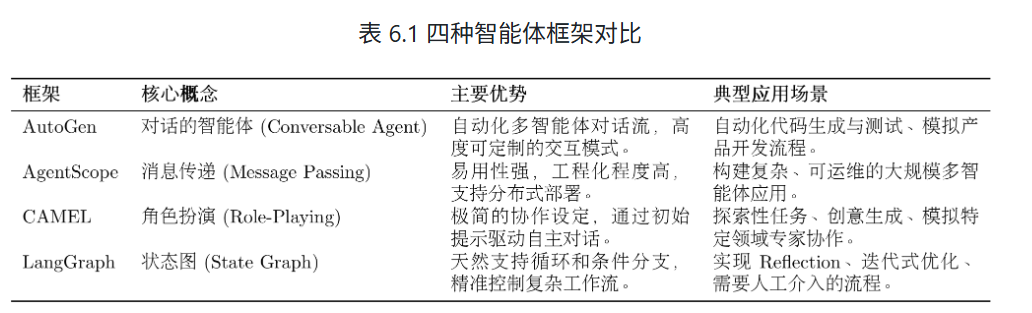
AutoGen：AutoGen 的核心思想是通过对话实现协作[1]。它将多智能体系统抽象为一个由多个“可对话”智能体组成的群聊。开发者可以定义不同角色（如 Coder, ProductManager, Tester），并设定它们之间的交互规则（例如，Coder 写完代码后由 Tester 自动接管）。任务的解决过程，就是这些智能体在群聊中通过自动化消息传递，不断对话、协作、迭代直至最终目标达成的过程。

AgentScope：AgentScope 是一个专为多智能体应用设计的、功能全面的开发平台[2]。它的核心特点是易用性和工程化。它提供了一套非常友好的编程接口，让开发者可以轻松定义智能体、构建通信网络，并管理整个应用的生命周期。其内置的消息传递机制和对分布式部署的支持，使其非常适合构建和运维复杂、大规模的多智能体系统。

CAMEL：CAMEL 提供了一种新颖的、名为角色扮演 (Role-Playing) 的协作方法[3]。其核心理念是，我们只需要为两个智能体（例如，AI研究员 和 Python程序员）设定好各自的角色和共同的任务目标，它们就能在“初始提示 (Inception Prompting)”的引导下，自主地进行多轮对话，相互启发、相互配合，共同完成任务。它极大地降低了设计多智能体对话流程的复杂度。

LangGraph：作为 LangChain 生态的扩展，LangGraph 另辟蹊径，将智能体的执行流程建模为图 (Graph)[4]。在传统的链式结构中，信息只能单向流动。而 LangGraph 将每一步操作（如调用LLM、执行工具）定义为图中的一个节点 (Node)，并用边 (Edge) 来定义节点之间的跳转逻辑。这种设计天然支持循环 (Cycles)，使得实现如 Reflection 这样的迭代、修正、自我反思的复杂工作流变得异常简单和直观。


## 6.2 框架一：AutoGen
AutoGen以对话驱动协作。它巧妙地将复杂的任务解决流程，映射为不同角色的智能体之间的一系列自动化对话。
### 6.2.1 AutoGen的核心机制
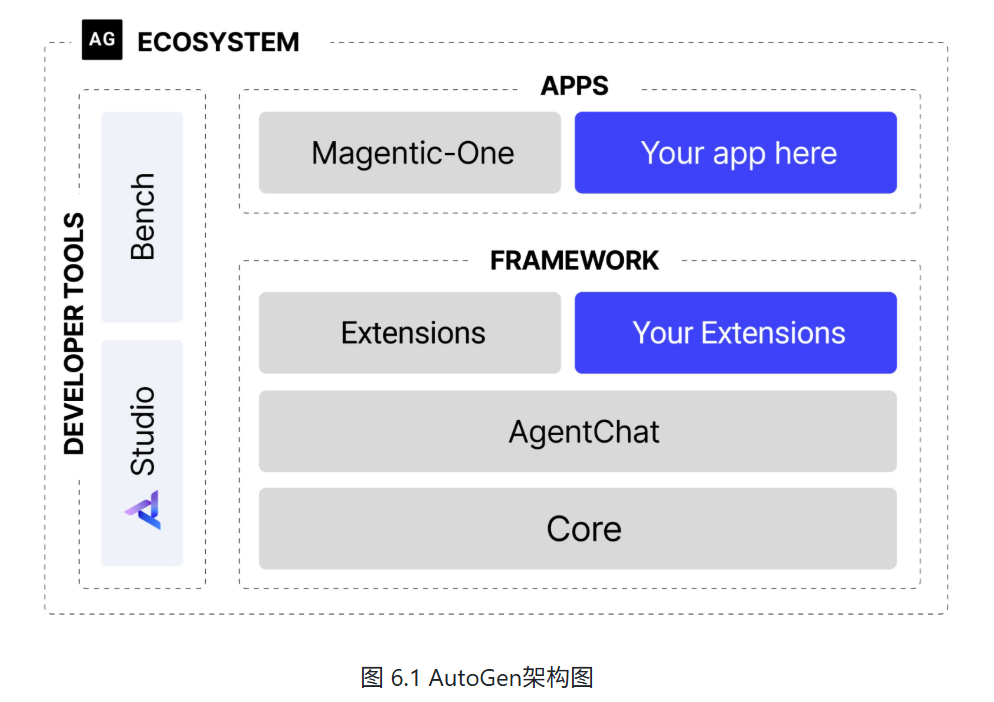
设计理念：
分层设计：autogen-core封装交互传递等核心功能和autogen-agentchat提供对话智能体应用的高级接口，简化开发流程  

异步优化：新架构全面转向异步编程，由于网络请求是主要耗时，异步允许等待时处理其他任务避免阻塞提升并发处理能力和系统资源利用率。

核心组件： AssistantAgent助理智能体，任务主要解决者封装LLM  和  UserProxyAgent用户代理智能体，扮演双重角色又发布任务又执行任务

从GroupChatManager到Team任务需要多个智能体合作就需要机制协调对话
：  轮询群聊，工作流
### 6.2.2 软件开发团队
在理解了 AutoGen 的核心组件与对话机制后，本节将通过一个完整的实战案例来具体展示如何应用这些新特性。我们将构建一个模拟的软件开发团队，该团队由多个具有不同专业技能的智能体组成，它们将协作完成一个真实的软件开发任务
#### （1）业务目的：开发Web应用：实时显示比特币当前价格；这个任务虽小，却完整地覆盖了软件开发的典型环节：从需求分析、技术选型、编码实现到代码审查和最终测试
#### （2）智能体团队角色：ProductManager产品经理，Engineer工程师，CodeReviewer代码审查员，UserProxy用户代理
### 6.2.3 核心代码实现
#### （1）模拟客户端配置
所有基于 LLM 的智能体都需要一个模型客户端来与语言模型进行交互。AutoGen 0.7.4 提供了标准化的 OpenAIChatCompletionClient，它可以方便地与任何兼容 OpenAI API 规范的模型服务（包括 OpenAI 官方服务、Azure OpenAI 以及本地模型服务如 Ollama等）进行对接。

我们通过一个独立的函数来创建和配置模型客户端，并通过环境变量管理 API Key 和服务地址，这是一种良好的工程实践，增强了代码的灵活性和安全性。

In [ ]:
from autogen_ext.models.openai import OpenAIChatCompletionClient

def create_openai_model_client():
    """创建并配置 OpenAI 模型客户端"""
    return OpenAIChatCompletionClient(
        model=os.getenv("LLM_MODEL_ID", "gpt-4o"),
        api_key=os.getenv("LLM_API_KEY"),
        base_url=os.getenv("LLM_BASE_URL", "https://api.openai.com/v1")
    )

#### （2）智能体角色定义
定义智能体的核心在于编写高质量的系统消息 (System Message)。系统消息就像是给智能体设定的“行为准则”和“专业知识库”，它精确地规定了智能体的角色、职责、工作流程，甚至是与其他智能体交互的方式。一个精心设计的系统消息是确保多智能体系统能够高效、准确协作的关键。在我们的软件开发团队中，我们为每一个角色都创建了一个独立的函数来封装其定义。
#### 产品经理
产品经理负责启动整个流程

In [ ]:
def create_product_manager(model_client):
    """创建产品经理智能体"""
    system_message = """你是一位经验丰富的产品经理，专门负责软件产品的需求分析和项目规划。

你的核心职责包括：
1. **需求分析**：深入理解用户需求，识别核心功能和边界条件
2. **技术规划**：基于需求制定清晰的技术实现路径
3. **风险评估**：识别潜在的技术风险和用户体验问题
4. **协调沟通**：与工程师和其他团队成员进行有效沟通

当接到开发任务时，请按以下结构进行分析：
1. 需求理解与分析
2. 功能模块划分
3. 技术选型建议
4. 实现优先级排序
5. 验收标准定义

请简洁明了地回应，并在分析完成后说"请工程师开始实现"。"""

    return AssistantAgent(
        name="ProductManager",
        model_client=model_client,
        system_message=system_message,
    )

#### 工程师
工程师的系统消息聚焦于技术实现

In [ ]:
def create_engineer(model_client):
    """创建软件工程师智能体"""
    system_message = """你是一位资深的软件工程师，擅长 Python 开发和 Web 应用构建。

你的技术专长包括：
1. **Python 编程**：熟练掌握 Python 语法和最佳实践
2. **Web 开发**：精通 Streamlit、Flask、Django 等框架
3. **API 集成**：有丰富的第三方 API 集成经验
4. **错误处理**：注重代码的健壮性和异常处理

当收到开发任务时，请：
1. 仔细分析技术需求
2. 选择合适的技术方案
3. 编写完整的代码实现
4. 添加必要的注释和说明
5. 考虑边界情况和异常处理

请提供完整的可运行代码，并在完成后说"请代码审查员检查"。"""

    return AssistantAgent(
        name="Engineer",
        model_client=model_client,
        system_message=system_message,
    )

#### 代码审查员
代码审查员的定义则侧重于代码的质量、安全性和规范性

In [ ]:
def create_code_reviewer(model_client):
    """创建代码审查员智能体"""
    system_message = """你是一位经验丰富的代码审查专家，专注于代码质量和最佳实践。

你的审查重点包括：
1. **代码质量**：检查代码的可读性、可维护性和性能
2. **安全性**：识别潜在的安全漏洞和风险点
3. **最佳实践**：确保代码遵循行业标准和最佳实践
4. **错误处理**：验证异常处理的完整性和合理性

审查流程：
1. 仔细阅读和理解代码逻辑
2. 检查代码规范和最佳实践
3. 识别潜在问题和改进点
4. 提供具体的修改建议
5. 评估代码的整体质量

请提供具体的审查意见，完成后说"代码审查完成，请用户代理测试"。"""

    return AssistantAgent(
        name="CodeReviewer",
        model_client=model_client,
        system_message=system_message,
    )

#### 用户代理
UserProxyAgent 是一个特殊的智能体，它不依赖 LLM 进行回复，而是作为用户在系统中的代理
它的 description 字段清晰地描述了其职责，尤其重要的是，它负责在任务最终完成后发出 TERMINATE 指令，以正常结束整个协作流程。

In [ ]:
def create_user_proxy():
    """创建用户代理智能体"""
    return UserProxyAgent(
        name="UserProxy",
        description="""用户代理，负责以下职责：
1. 代表用户提出开发需求
2. 执行最终的代码实现
3. 验证功能是否符合预期
4. 提供用户反馈和建议

完成测试后请回复 TERMINATE。""",
    )

#### （3） 定义团队协作流程
在本案例中，软件开发的流程是相对固定的（需求->编码->审查->测试），因此 RoundRobinGroupChat (轮询群聊) 是理想的选择。我们按照业务逻辑顺序，将四个智能体加入到参与者列表中。

In [ ]:
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination

# 定义团队聊天和协作规则
team_chat = RoundRobinGroupChat(
    participants=[
        product_manager,
        engineer,
        code_reviewer,
        user_proxy
    ],
    termination_condition=TextMentionTermination("TERMINATE"),
    max_turns=20,
)

参与者顺序: participants 列表的顺序决定了智能体发言的先后次序。

终止条件: termination_condition 是控制协作流程何时结束的关键。这里我们设定，当任何消息中包含关键词 "TERMINATE" 时，对话便结束。在我们的设计中，这个指令由 UserProxy 在完成最终测试后发出。

最大轮次: max_turns 是一个安全阀，用于防止对话陷入无限循环，避免不必要的资源消耗。
#### （4） 启动与运行
由于 AutoGen 0.7.4 采用异步架构，整个协作流程的启动和运行都在一个异步函数中完成，并最终通过 asyncio.run() 来执行

In [ ]:
async def run_software_development_team():
    # ... 初始化客户端和智能体 ...
    
    # 定义任务描述
    task = """我们需要开发一个比特币价格显示应用，具体要求如下：
            核心功能：
            - 实时显示比特币当前价格（USD）
            - 显示24小时价格变化趋势（涨跌幅和涨跌额）
            - 提供价格刷新功能

            技术要求：
            - 使用 Streamlit 框架创建 Web 应用
            - 界面简洁美观，用户友好
            - 添加适当的错误处理和加载状态

            请团队协作完成这个任务，从需求分析到最终实现。"""
    
    # 异步执行团队协作，并流式输出对话过程
    result = await Console(team_chat.run_stream(task=task))
    return result

# 主程序入口
if __name__ == "__main__":
    result = asyncio.run(run_software_development_team())

当程序运行时，task 作为初始消息被传入 team_chat，产品经理作为第一个参与者接收到该消息，随后整个自动化协作流程便开始了。

#### （5）预期协作效果

当我们运行这个软件开发团队时，可以观察到一个完整的协作流程：

In [ ]:
🔧 正在初始化模型客户端...
👥 正在创建智能体团队...
🚀 启动 AutoGen 软件开发团队协作...
============================================================
---------- TextMessage (user) ----------
我们需要开发一个比特币价格显示应用，具体要求如下：
...
请团队协作完成这个任务，从需求分析到最终实现。
---------- TextMessage (ProductManager) ----------
### 1. 需求理解与分析
...
请工程师开始实现。
---------- TextMessage (Engineer) ----------
### 技术方案实施
...
请代码审查员检查。
---------- TextMessage (CodeReviewer) ----------
### 代码审查
...
代码审查完成，请用户代理测试。    
---------- TextMessage (UserProxy) ----------
已经完成需求
---------- TextMessage (ProductManager) ----------
太好了，感谢您的反馈！如果在使用过程中有任何问题，或者有其他功能需求和改进建议，请随时告知我们。我们会持续提供支持和改进。期待您对我们的应用
有愉快的使用体验！
---------- TextMessage (Engineer) ----------
很高兴听到项目顺利完成。如果您或用户有任何问题或者需要帮助，请随时联系我们。感谢您对我们工作的支持，让我们一起确保应用稳定运行并不断优化用户
体验！
---------- TextMessage (CodeReviewer) ----------
非常感谢大家的努力与协作，使得项目能够顺利完成。未来若有更多技术支持的需求或者需要改进的地方，我们愿意为项目的持续优化贡
献力量。期待用户能够享受到流畅的体验，同时也欢迎提出更多的反馈与建议。再次感谢团队的合作！
---------- TextMessage (UserProxy) ----------
Enter your response: TERMINATE
============================================================
✅ 团队协作完成！

📋 协作结果摘要：
- 参与智能体数量：4个
- 任务完成状态：成功

非openai模型的配置补充；以DeepSeek为例：

In [ ]:
from autogen_ext.models.openai import OpenAIChatCompletionClient

model_client = OpenAIChatCompletionClient(
    model="deepseek-chat",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com/v1",
    model_info={
        "function_calling": True,
        "max_tokens": 4096,
        "context_length": 32768,
        "vision": False,
        "json_output": True,
        "family": "deepseek",
        "structured_output": True,
    }
)

##  框架四LangGraph
### 6.5.1 LangGraph的结构梳理
这个智能体的执行流程建模为一种状态机，并将其表示为有向图，在这种范式中图的节点代表一个具体的步骤而边则定义了从一个节点到另一个节点的跳转逻辑

三个基本构成要素：

首先就是全局状态：整个图的执行过程都围绕一个共享的状态对象进行。这个状态通常被定义为一个 Python 的 TypedDict，它可以包含任何你需要追踪的信息，如对话历史、中间结果、迭代次数等。所有的节点都能读取和更新这个中心状态。

In [ ]:
from typing import TypedDict, List

# 定义全局状态的数据结构
class AgentState(TypedDict):
    messages: List[str]      # 对话历史
    current_task: str        # 当前任务
    final_answer: str        # 最终答案
    # ... 任何其他需要追踪的状态

其次，是节点（Nodes）。每个节点都是一个接收当前状态作为输入、并返回一个更新后的状态作为输出的 Python 函数。节点是执行具体工作的单元。

In [ ]:
# 定义一个“规划者”节点函数
def planner_node(state: AgentState) -> AgentState:
    """根据当前任务制定计划，并更新状态。"""
    current_task = state["current_task"]
    # ... 调用LLM生成计划 ...
    plan = f"为任务 '{current_task}' 生成的计划..."
    
    # 将新消息追加到状态中
    state["messages"].append(plan)
    return state

# 定义一个“执行者”节点函数
def executor_node(state: AgentState) -> AgentState:
    """执行最新计划，并更新状态。"""
    latest_plan = state["messages"][-1]
    # ... 执行计划并获得结果 ...
    result = f"执行计划 '{latest_plan}' 的结果..."
    
    state["messages"].append(result)
    return state

最后，是边（Edges）。边负责连接节点，定义工作流的方向。最简单的边是常规边，它指定了一个节点的输出总是流向另一个固定的节点。而 LangGraph 最强大的功能在于条件边（Conditional Edges）。它通过一个函数来判断当前的状态，然后动态地决定下一步应该跳转到哪个节点。这正是实现循环和复杂逻辑分支的关键。

In [ ]:
def should_continue(state: AgentState) -> str:
    """条件函数：根据状态决定下一步路由。"""
    # 假设如果消息少于3条，则需要继续规划
    if len(state["messages"]) < 3:
        # 返回的字符串需要与添加条件边时定义的键匹配
        return "continue_to_planner"
    else:
        state["final_answer"] = state["messages"][-1]
        return "end_workflow"

在定义了状态、节点和边之后，我们可以像搭积木一样将它们组装成一个可执行的工作流。

In [ ]:
from langgraph.graph import StateGraph, END

# 初始化一个状态图，并绑定我们定义的状态结构
workflow = StateGraph(AgentState)

# 将节点函数添加到图中
workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)

# 设置图的入口点
workflow.set_entry_point("planner")

# 添加常规边，连接 planner 和 executor
workflow.add_edge("planner", "executor")

# 添加条件边，实现动态路由
workflow.add_conditional_edges(
    # 起始节点
    "executor",
    # 判断函数
    should_continue,
    # 路由映射：将判断函数的返回值映射到目标节点
    {
        "continue_to_planner": "planner", # 如果返回"continue_to_planner"，则跳回planner节点
        "end_workflow": END               # 如果返回"end_workflow"，则结束流程
    }
)

# 编译图，生成可执行的应用
app = workflow.compile()

# 运行图
inputs = {"current_task": "分析最近的AI行业新闻", "messages": []}
for event in app.stream(inputs):
    print(event)

### 6.5.2 三步问答助手
在理解了 LangGraph 的核心概念之后，我们将通过一个实战案例来巩固所学。我们将构建一个简化的问答对话助手，它会遵循一个清晰、固定的三步流程来回答用户的问题：

理解 (Understand)：首先，分析用户的查询意图。

搜索 (Search)：然后，模拟搜索与意图相关的信息。

回答 (Answer)：最后，基于意图和搜索到的信息，生成最终答案。

#### （1）定义全局状态
首先，我们需要定义一个贯穿整个工作流的全局状态。这是一个共享的数据结构，它在图的每个节点之间传递，作为工作流的持久化上下文。 每个节点都可以读取该结构中的数据，并对其进行更新。

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class SearchState(TypedDict):
    messages: Annotated[list, add_messages]
    user_query: str      # 经过LLM理解后的用户需求总结
    search_query: str    # 优化后用于Tavily API的搜索查询
    search_results: str  # Tavily搜索返回的结果
    final_answer: str    # 最终生成的答案
    step: str            # 标记当前步骤

#### （2）第二步
#### 定义工作流节点：接收作输入更新作输出，

#### 理解查询节点：理解用户意图 

#### 搜索节点：调用api进行真实互联网搜索搜索失败就会状态被下一个节点触发备用方案

#### 回答流节点：搜索成功用有时效且有据可依的回答，若没有搜索成功则利用LLM的内部知识回答生成最终答案

In [ ]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from tavily import TavilyClient

# 加载 .env 文件中的环境变量
load_dotenv()

# 初始化模型
# 我们将使用这个 llm 实例来驱动所有节点的智能
llm = ChatOpenAI(
    model=os.getenv("LLM_MODEL_ID", "gpt-4o-mini"),
    api_key=os.getenv("LLM_API_KEY"),
    base_url=os.getenv("LLM_BASE_URL", "https://api.openai.com/v1"),
    temperature=0.7
)
# 初始化Tavily客户端
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [ ]:
def understand_query_node(state: SearchState) -> dict:
    """步骤1：理解用户查询并生成搜索关键词"""
    user_message = state["messages"][-1].content
    
    understand_prompt = f"""分析用户的查询："{user_message}"
请完成两个任务：
1. 简洁总结用户想要了解什么
2. 生成最适合搜索引擎的关键词（中英文均可，要精准）

格式：
理解：[用户需求总结]
搜索词：[最佳搜索关键词]"""

    response = llm.invoke([SystemMessage(content=understand_prompt)])
    response_text = response.content
    
    # 解析LLM的输出，提取搜索关键词
    search_query = user_message # 默认使用原始查询
    if "搜索词：" in response_text:
        search_query = response_text.split("搜索词：")[1].strip()
    
    return {
        "user_query": response_text,
        "search_query": search_query,
        "step": "understood",
        "messages": [AIMessage(content=f"我将为您搜索：{search_query}")]
    }

In [ ]:
def tavily_search_node(state: SearchState) -> dict:
    """步骤2：使用Tavily API进行真实搜索"""
    search_query = state["search_query"]
    try:
        print(f"🔍 正在搜索: {search_query}")
        response = tavily_client.search(
            query=search_query, search_depth="basic", max_results=5, include_answer=True
        )
        # ... (处理和格式化搜索结果) ...
        search_results = ... # 格式化后的结果字符串
        
        return {
            "search_results": search_results,
            "step": "searched",
            "messages": [AIMessage(content="✅ 搜索完成！正在整理答案...")]
        }
    except Exception as e:
        # ... (处理错误) ...
        return {
            "search_results": f"搜索失败：{e}",
            "step": "search_failed",
            "messages": [AIMessage(content="❌ 搜索遇到问题...")]
        }

In [ ]:
def generate_answer_node(state: SearchState) -> dict:
    """步骤3：基于搜索结果生成最终答案"""
    if state["step"] == "search_failed":
        # 如果搜索失败，执行回退策略，基于LLM自身知识回答
        fallback_prompt = f"搜索API暂时不可用，请基于您的知识回答用户的问题：\n用户问题：{state['user_query']}"
        response = llm.invoke([SystemMessage(content=fallback_prompt)])
    else:
        # 搜索成功，基于搜索结果生成答案
        answer_prompt = f"""基于以下搜索结果为用户提供完整、准确的答案：
用户问题：{state['user_query']}
搜索结果：\n{state['search_results']}
请综合搜索结果，提供准确、有用的回答..."""
        response = llm.invoke([SystemMessage(content=answer_prompt)])
    
    return {
        "final_answer": response.content,
        "step": "completed",
        "messages": [AIMessage(content=response.content)]
    }

然后构件图将节点连接起来

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

def create_search_assistant():
    workflow = StateGraph(SearchState)
    
    # 添加节点
    workflow.add_node("understand", understand_query_node)
    workflow.add_node("search", tavily_search_node)
    workflow.add_node("answer", generate_answer_node)
    
    # 设置线性流程
    workflow.add_edge(START, "understand")
    workflow.add_edge("understand", "search")
    workflow.add_edge("search", "answer")
    workflow.add_edge("answer", END)
    
    # 编译图
    memory = InMemorySaver()
    app = workflow.compile(checkpointer=memory)
    return app

运行结果展示：

In [ ]:
🔍 智能搜索助手启动！
我会使用Tavily API为您搜索最新、最准确的信息
支持各种问题：新闻、技术、知识问答等
(输入 'quit' 退出)

🤔 您想了解什么: 明天我要去北京，天气怎么样？有合适的景点吗

============================================================
🧠 理解阶段: 我理解您的需求：理解：用户想了解明天北京的天气情况以及合适的景点推荐。  
搜索词：北京 明天 天气 景点推荐 Beijing weather tomorrow attractions
🔍 正在搜索: 北京 明天 天气 景点推荐 Beijing weather tomorrow attractions
🔍 搜索阶段: ✅ 搜索完成！找到了相关信息，正在为您整理答案...

💡 最终回答:
明天（2025年9月17日）北京的天气预报显示，预计将是多云，气温范围在17°C（62°F）到25°C（77°F）之间。这种温和的天气非常适合户外活动。

### 合适的景点推荐：
1. **长城**：作为中国最著名的历史遗址之一，长城是必游之地。你可以选择八达岭或慕田峪这些较为受欢迎的段落进行游览。

2. **故宫**：故宫是明清两代的皇宫，拥有丰富的历史和文化，适合对中国历史感兴趣的游客。

3. **天安门广场**：这是中国的象征之一，广场上有许多重要的建筑和纪念碑，适合拍照留念。

4. **颐和园**：一个非常美丽的皇家园林，适合漫步和欣赏自然风光，尤其是湖泊和古建筑。

5. **798艺术区**：如果你对现代艺术感兴趣，798艺术区是一个集艺术、文化和创意于一体的地方，适合探索和拍摄。

### 小贴士：
- 由于明天天气良好，建议提前规划出行路线，并准备一些水和小吃，以便在游览时保持充足的体力。
- 由于天气变化可能会影响游览体验，建议查看实时天气更新。

希望这些信息能帮助你安排一个愉快的北京之旅！如果你需要更多关于景点的信息或者旅行建议，欢迎随时询问。

============================================================

🤔 您想了解什么: